In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

from george import kernels
import george
from astropy.io import fits
from functions import *
from gp_model_params import info
from glob import glob
from tqdm import tqdm
import pickle as pkl
from scipy.signal import find_peaks

Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'functions'

In [ ]:
from pathlib import Path
home = str(Path.home())

In [18]:
# Read and apply Roman noise function
noise_fun = noise_function('cycle6_snr_curve.txt')

In [42]:
tp = 'LPV'
direc = home+'/Research_data/Bulge_Variables/%s/'%tp
direc_list = np.sort(glob(direc+'*.fits'))
list_periods = np.genfromtxt(home+'/Research_data/Bulge_Variables/%s/BLG_%s_OGLE_periods.txt'%(tp,tp)
                            , dtype='str')

In [43]:
# Read Roman time sampling
t_new = np.loadtxt('lc_example/ulwdc1_208_W149.txt', usecols=0)
t_new = t_new - min(t_new)

In [44]:
# info[tp]['p0'][1] = 0.5
# info[tp]['n_phs'] = 3
# info[tp]['gp_opt_s_param'] =.01
# info[tp]['fit_binned'] = False
# info[tp]['gp_opt'] = True

In [45]:
len(direc_list)

4411

In [47]:
lists = direc_list #[71:72]
all_templates = {}
counter = 0
stds = []
peaks = []
for j, path in tqdm(enumerate(lists)):

    # info[tp]['n_phs'] = 5
    
    ID = path.split('/')[-1].split('_')[0]
    # print(ID)
    
    # if not path.split('/')[-1].split('_')[0].split('-')[-1] == '002015':
    #     continue
    
    
    period = float(list_periods[list_periods[:, 0] == ID][0][1])
    
    period, df = read_fits(path, period=period,
                           tp = tp)
    
    print(len(df[df.band=='I']))
    # if info[tp]['n_phs']*period>1713.99:
    #     info[tp]['n_phs'] = (1713.99/period) - (1713.99/period)%1
    
#     if np.isnan(period):
#         pass
#     try:
#         df = df[df.band=='I']
#     except AttributeError:
#         continue
        
#     df = df.reset_index(drop=True)

#     if np.min(df.t)>0:
#         df.t = df.t - np.min(df.t)


#     if (np.max(df.t))<1713:
#         df = add_last_point(df, period)
#     df_modified = gap_reducer(df, period, info[tp])
#     if (np.max(df_modified.t))<1713 and np.isinf(info[tp]['n_phs']):
#         df_modified = extend_baseline(df_modified, period)
#     while np.max(df_modified.t.values)<1713+period:
#         len_0 = np.diff(df_modified.t.values)
#         df_modified = gap_reducer(df_modified, period, info[tp])
#         len_1 = np.diff(df_modified.t.values)
#         if np.max(df_modified.t.values)>1713:
#             break
#         if np.sum(len_0>50) == np.sum(len_1>50):
#             break

#     gp = prep_gp(info[tp], period)
#     x, y, e = prep_input(df_modified, tp, period, info[tp])
    
#     if len(x)/10>1000:
#         xfit, yfit, efit, X = binning_data(x, y, e, info[tp], n_bins=int(len(x)/100), verbose=False)
#     else: 
#         xfit, yfit, efit, X = binning_data(x, y, e, info[tp], n_bins=np.nan, verbose=False)


# #     # Compute histogram
# #     counts, bins = np.histogram(df_modified.m.values, bins=10)

# #     # Find peaks
# #     peaks_tmp, _ = find_peaks(counts)

#     # Print number of peaks
#     # print(f"Number of peaks: {len(peaks)}")
#     # if len(peaks) > 1:
#     #     print("The histogram is bimodal.")
#     #     print(np.abs(bins[peaks[0]]-bins[peaks[1]]))
#     # else:
#     #     print("The histogram is not bimodal.")
#     # stds.append(len(peaks_tmp))
#     # if len(peaks_tmp) <2:
#     #     peaks.append(0)
#     # else:
#     #     peaks.append(np.abs(bins[peaks_tmp[0]]-bins[peaks_tmp[1]]))
    
#     # print(len(x))
#     if len(x)>1000 and info[tp]['fit_binned']==False:
#         info[tp]['fit_binned'] = True
#         info[tp]['n_bins'] = 500
#     y_median = np.median(y)
#     gp = fit_gp(xfit, yfit, efit, info[tp], gp)
#     mu2, cov = gp.predict(yfit, x)
#     # if np.sum((y-(mu2+y_median))**2/(e**2))/len(y)>500:
#     #     info[tp]['gp_opt'] = True
#     #     gp, xfit, yfit = fit_gp(x, y, e, info[tp], gp)
#     t_prime = X
#     try:
#         df_roman, t_prime_new,  mu_new,mu, std = predict_gp(gp, 
#                                                         yfit, 
#                                                         y_median, 
#                                                         t_prime, 
#                                                         t_new, 
#                                                         info[tp], 
#                                                         period, 
#                                                         noise_fun)
#     except:
#         continue
        
#     mu2, cov = gp.predict(yfit, x)
#     if np.sum((y-(mu2+y_median))**2/(e**2))/len(y)>500:
#         continue
#     counter += 1
#     all_templates[ID] = {}
#     all_templates[ID]['period'] = period
#     all_templates[ID]['OGLE_I'] = df.m.values
#     all_templates[ID]['OGLE_time'] = df.t.values
#     all_templates[ID]['Roman_resampled'] = (df_roman.m).values+y_median
    
#     plt.figure()
#     plt.errorbar(x, y, yerr=e, fmt = '.', ms = 10, label = 'OGLE data')
#     plt.plot(t_prime, mu+y_median, linewidth = 4, label='GP model', zorder=11)
#     plt.title('GP fit for %s, period=%.2f days'%(ID, period))
#     plt.xlabel('Time (days)')
#     plt.ylabel('Magnitude')
    
#     plt.text(0.05, 
#              0.05, 
#              np.sum((y-(mu2+y_median))**2/(e**2))/len(y), 
#              transform = plt.gca().transAxes)
    
#     if (counter/10)%1 == 0:
#         print('Collected %i events!'%counter)
#     if counter == 100:
#         break
    
    
    
    

    
    

6it [00:00, 193.42it/s]

71
71
70
71
71
68
No data found. Exit!


AttributeError: 'float' object has no attribute 'band'

In [16]:
IDs = list(all_templates.keys())

In [60]:
lists[np.asarray(peaks)>0.5]

array(['/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0078_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0091_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0098_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0116_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0144_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0224_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0229_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0345_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0350_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T2CEP/OGLE-BLG-T2CEP-0352_multiband_lc.fits',
       '/Users/somayeh/Downloads/Bulge_Variables/T

In [ ]:
pkl.dump(all_templates, 
         open('output/%s_Roman_lc_%i.pkl' %(tp, counter),
              'wb'))

In [18]:
plt.plot(t_new, all_templates[IDs[59]]['Roman_resampled'], '.')

IndexError: list index out of range

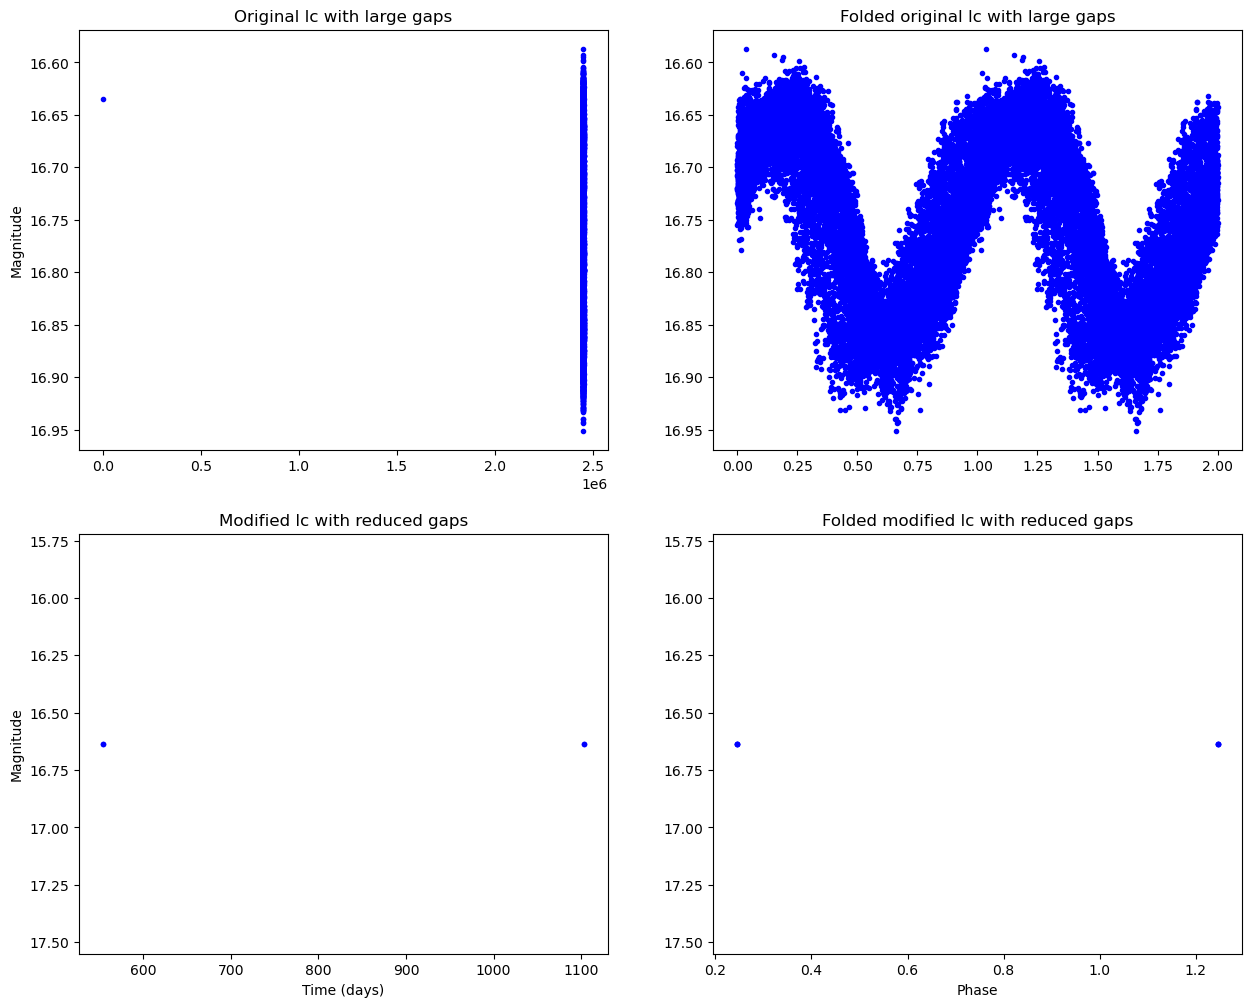

In [19]:
fig, axs = plt.subplots(2, 2)




axs[0,0].plot(df.t, df.m,'b.')
axs[0,1].plot(df.phase, df.m,'b.')
axs[0,1].plot(df.phase+1, df.m,'b.')

axs[1,0].plot(df_modified.t, df_modified.m,'b.')
axs[1,1].plot(df_modified.phase, df_modified.m,'b.')
axs[1,1].plot(df_modified.phase+1, df_modified.m,'b.')



axs[0,0].invert_yaxis()
axs[0,1].invert_yaxis()
axs[1,1].invert_yaxis()
axs[1,0].invert_yaxis()

axs[0,0].set_ylabel('Magnitude')
axs[0,0].set_title('Original lc with large gaps')
axs[0,1].set_title('Folded original lc with large gaps')
axs[1,0].set_ylabel('Magnitude')
axs[1,0].set_title('Modified lc with reduced gaps')
axs[1,1].set_title('Folded modified lc with reduced gaps')

axs[1,0].set_xlabel('Time (days)')
axs[1,1].set_xlabel('Phase')




fig = plt.gcf()
fig.set_size_inches(15.0,12.0)

In [13]:
period

10.5414944

NameError: name 'x' is not defined

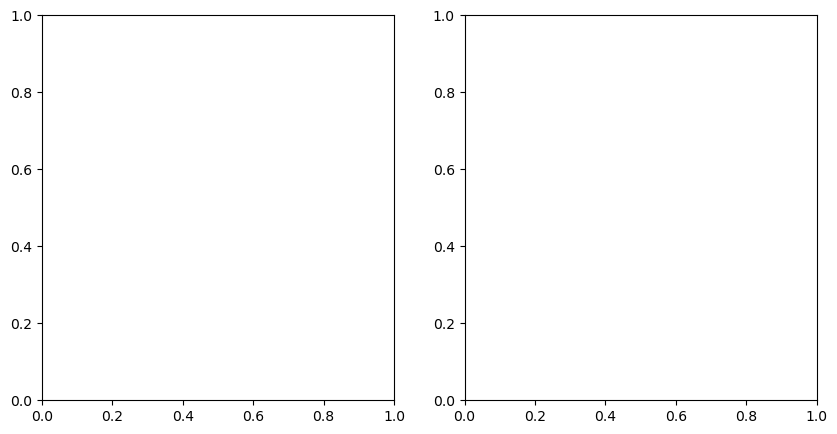

In [14]:
fig, axs = plt.subplots(1,2, figsize=(10, 5))
if np.isinf(info[tp]['n_phs']):
    tmp_period = period
else:
    tmp_period = 1/info[tp]['n_phs']
    
axs[0].errorbar(x, y, yerr=e, fmt = '.', ms = 10, label = 'OGLE data')

# axs[0].plot(bin_middles, bin_means, '.', zorder=11, label = 'Binned OGLE data')
axs[0].plot(t_prime,mu+y_median, linewidth = 4, label='GP model', zorder=11)
# axs[0].set_xlabel('%i Phases'%info[tp]['n_phs'], size=15)
axs[0].set_ylabel('Magnitude', size=15)
axs
axs[0].legend()
axs[0].invert_yaxis()

axs[1].errorbar((x/tmp_period)%1, y,yerr=e, fmt = '.', ms = 10, label = 'Folded OGLE data')

# axs[1].plot((bin_middles/tmp_period)%1, bin_means, '.', zorder=11, label='Binned OGLE data')
axs[1].plot((t_prime/tmp_period)%1,mu+y_median,'.', linewidth = 4, label='Folded GP model', zorder=11)
axs[1].set_xlabel('One Phase', size=15)
axs[1].set_ylabel('Magnitude', size=15)
axs[1].legend()
axs[1].invert_yaxis()

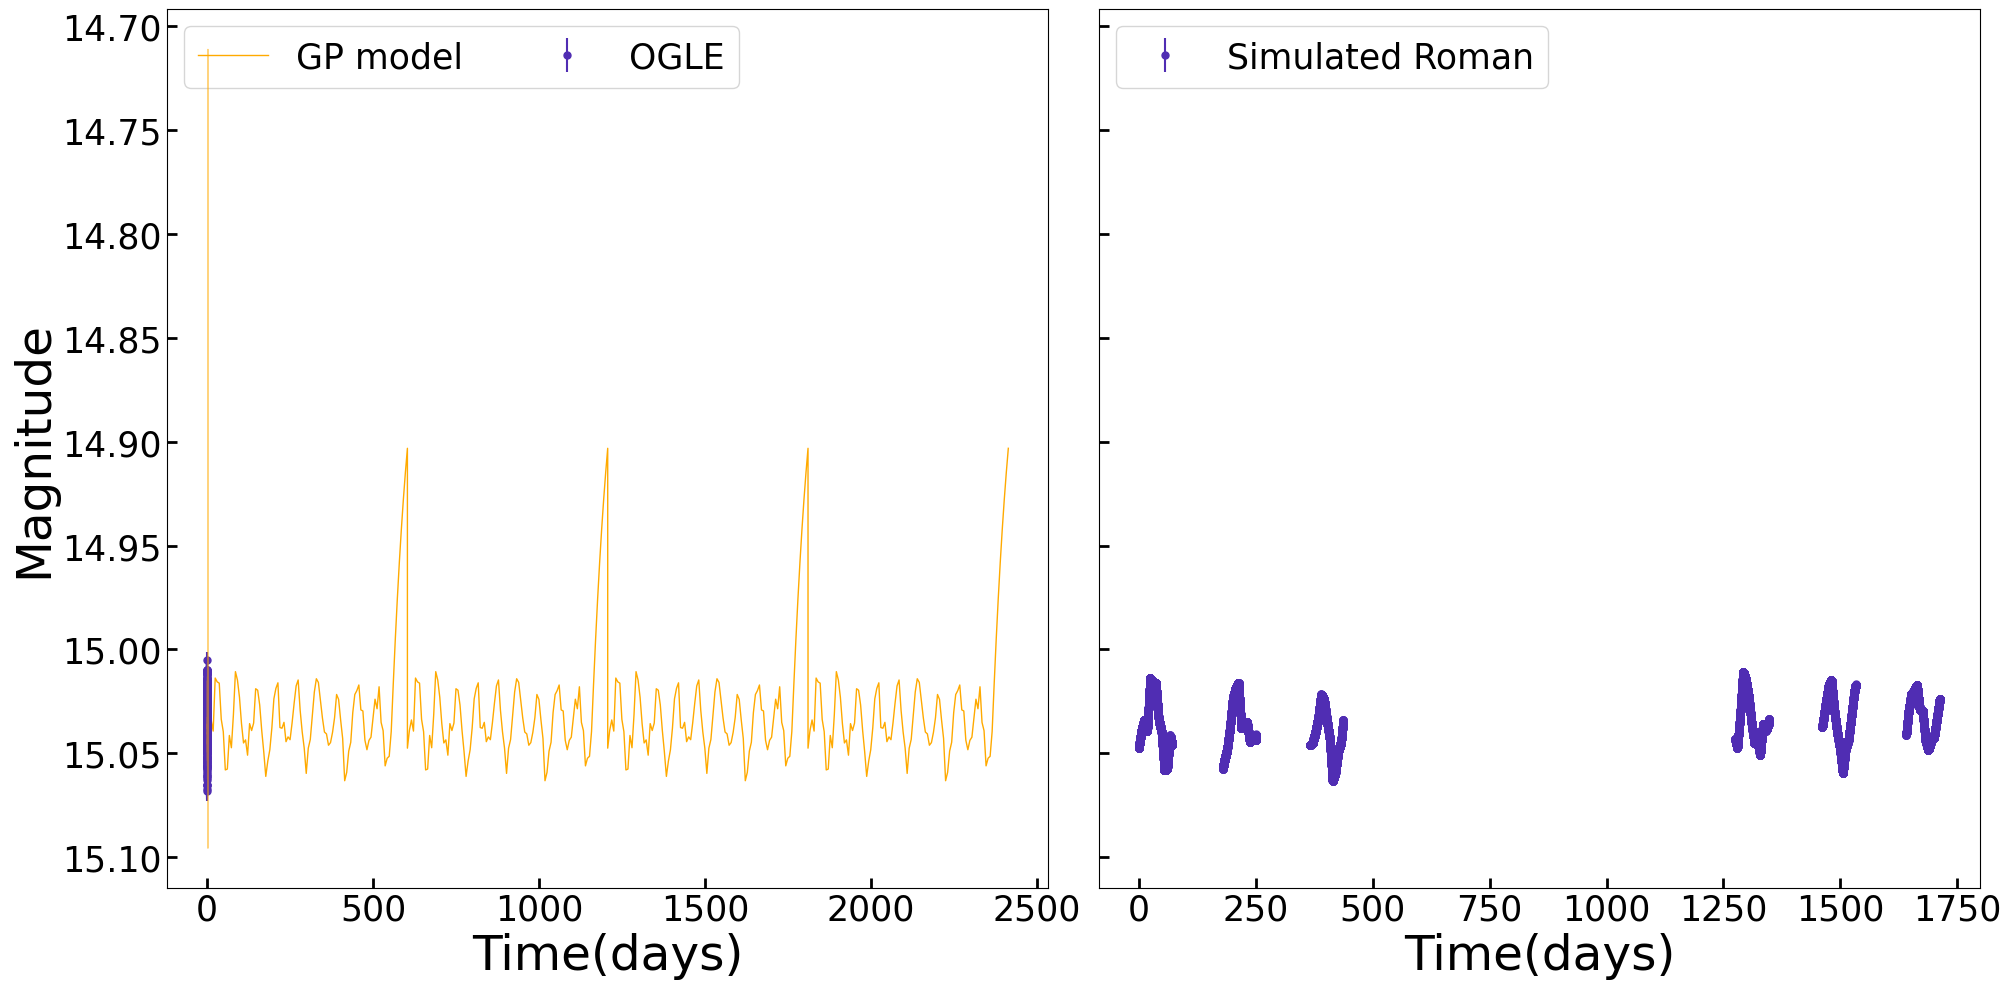

In [40]:
fig, ax = plt.subplots(1,2,figsize=(20,10), sharey=True)

data_color = '#502db3'
gp_color = '#ffaa00'

ax[0].errorbar(x, 
               y,
               yerr=e, 
               fmt = '.', 
               ms=10, 
               color = data_color,
               label='OGLE')
ax[0].plot(t_prime_new, 
           mu_new+y_median, 
           color = gp_color,
           label='GP model', 
           linewidth=1)
ax[0].fill_between(t_prime, 
                   mu+y_median-std, 
                   mu+y_median+std, 
                   color = gp_color,
                   alpha=0.5,
                  zorder=11)

ax[0].set_xlabel('Time(days)', size=35)
ax[0].set_ylabel('Magnitude', size=35)
# plt.title(info.ID[i], size=25)
ax[0].tick_params(axis="both", direction="in", which="major", right=False, top=False, size=7, labelsize=25, width = 2)
ax[0].legend(loc = 2, ncols=2, prop={'size':25})


ax[1].errorbar(df_roman.t, 
               df_roman.m+y_median,
               yerr=df_roman.e, 
               color = data_color,
               fmt = '.', 
               ms=10, 
               label='Simulated Roman')
ax[1].set_xlabel('Time(days)', size=35)
ax[1].tick_params(axis="both", direction="in", which="major", right=False, top=False, size=7, labelsize=25, width = 2)
ax[1].legend(loc = 2,prop={'size':25})
fig.tight_layout()
ax[0].invert_yaxis()
# plt.savefig('OGLE_%s_full_lc_to_Roman_with_GP_model.jpg'%tp,facecolor='white', edgecolor='none', bbox_inches='tight')

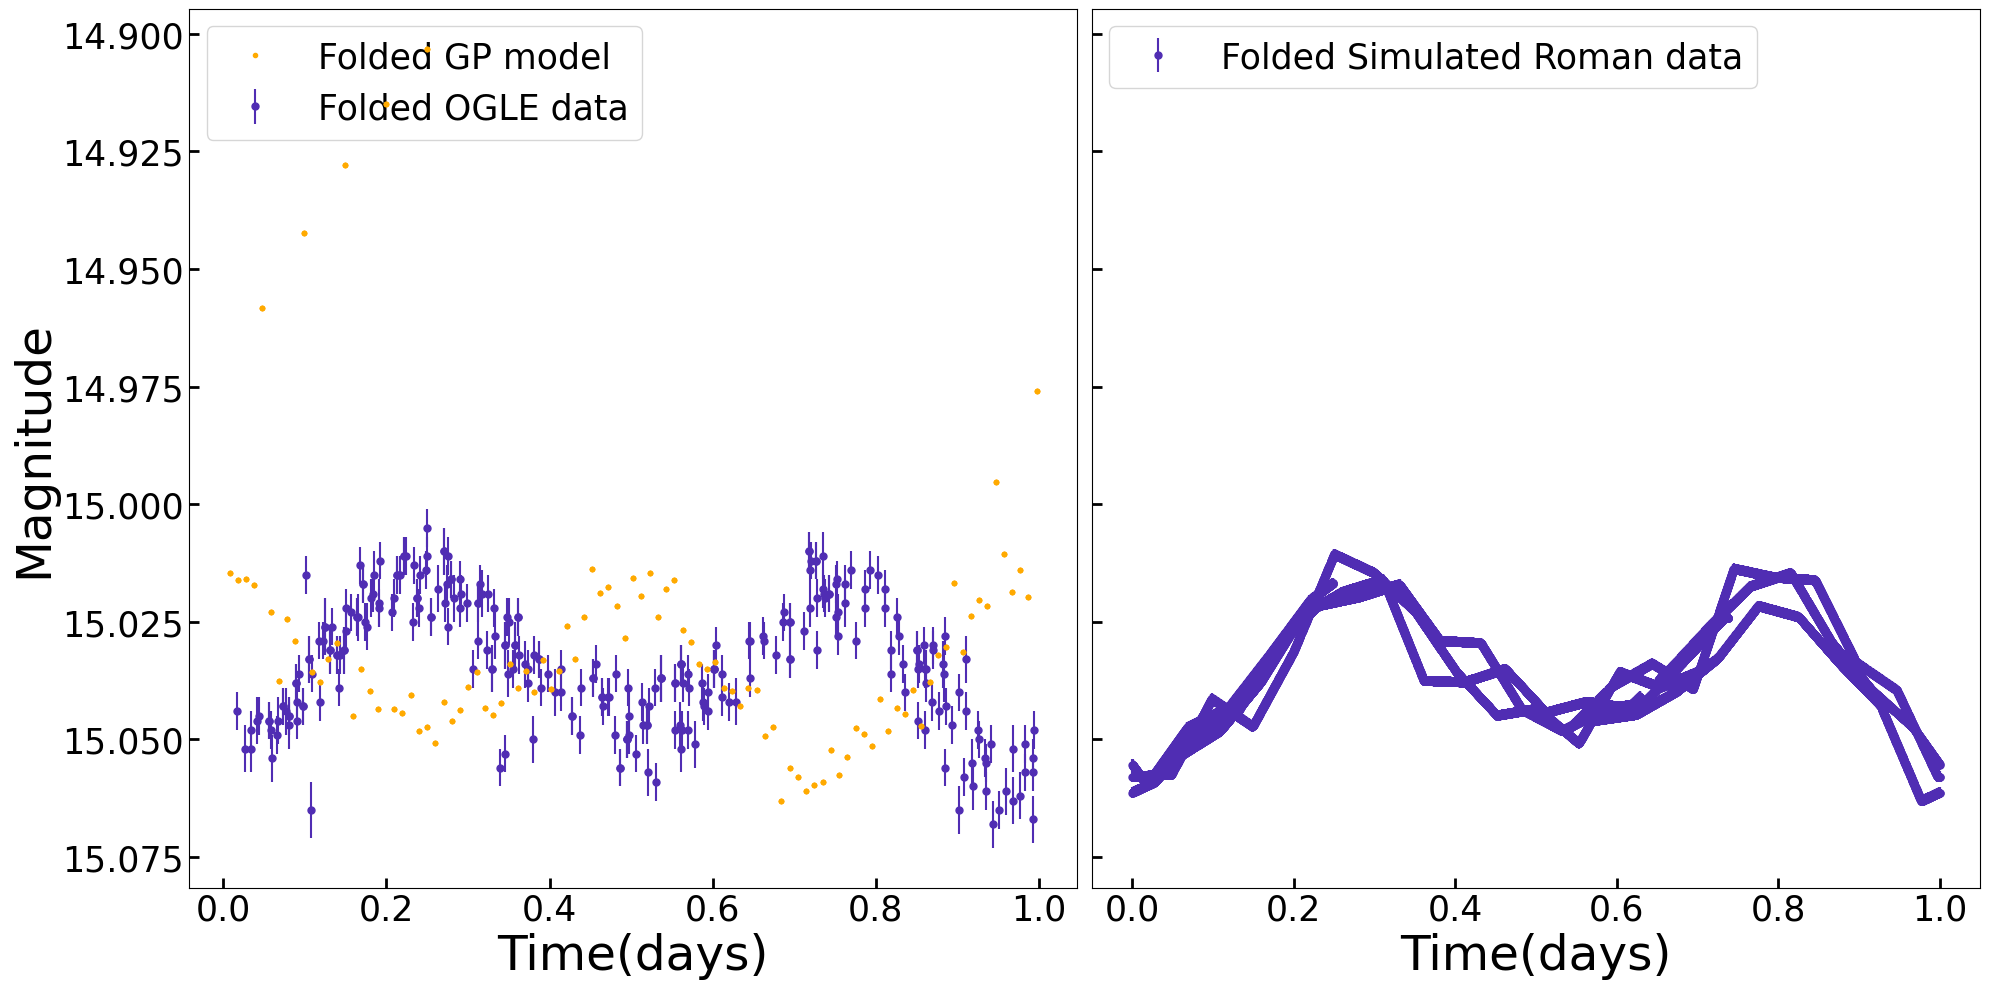

In [41]:
fig, ax = plt.subplots(1,2,figsize=(20,10), sharey=True)

t_prime_phase = T_0_fixer(t_prime_new, 
                          mu_new,
                          period, 
                          (t_prime_new/period)%1)
t_Roman_phase = T_0_fixer(df_roman.t.values, 
                          df_roman.m.values,
                          period, 
                          (df_roman.t.values/period)%1)

ax[0].errorbar(df_modified.phase, 
               df_modified.m,
               yerr=df_modified.e, 
               color = data_color,
               fmt = '.', 
               ms=10, 
               label='Folded OGLE data')
ax[0].plot(t_prime_phase[np.argsort(t_prime_phase)], 
           mu_new[np.argsort(t_prime_phase)]+y_median, 
           '.',
           color = gp_color,
           label='Folded GP model', 
           zorder=11)
ax[0].set_xlabel('Time(days)', size=35)
ax[0].set_ylabel('Magnitude', size=35)
ax[0].tick_params(axis="both", direction="in", which="major", right=False, top=False, size=7, labelsize=25, width = 2)
ax[0].legend(loc = 2,prop={'size':25})


ax[1].errorbar(t_Roman_phase, 
               df_roman.m+y_median,
               yerr=df_roman.e, 
               fmt = '.', 
               color = data_color,
               ms=10, 
               label='Folded Simulated Roman data')
ax[1].set_xlabel('Time(days)', size=35)
ax[1].tick_params(axis="both", direction="in", which="major", right=False, top=False, size=7, labelsize=25, width = 2)
ax[1].legend(loc = 2,prop={'size':25})
fig.tight_layout()
ax[0].invert_yaxis()
# plt.savefig('OGLE_%s_folded_lc_to_Roman_with_GP_model.jpg'%tp,facecolor='white', edgecolor='none', bbox_inches='tight')